# 33. 약리학 에이전트 + 활성보존 통합 리포트

## 이번 노트북에서 할 것
- 활성보존 근사 지표 함수(compute_activity_preservation_metrics,
  classify_activity_risk_v3) 정식 구현
- 약리학 에이전트(LLM) 구현 - 정량 지표를 근거로 최종 코멘트/사람검토
  필요 여부 판단
- 치환 근거 + 정량지표 + 구조이미지를 하나로 묶은 통합 리포트 함수
- (시간 되면) 독성학/의약화학/약리학 3에이전트 분리 + 조정자 로직

## 배경 (32까지)
- 라이브러리 32개 규칙, 커버리지 31.5%+, 4-endpoint 교차검증
- 남은 stuck 케이스 전부 재시도로직 수정으로 해결 확인(thioester,
  catechol, Three-membered_heterocycle 자체는 해결, cyclooctane_1은
  보류 결정)
- 외부평가(80/100)+지도교수 피드백: 활성/표적결합 고려 필요,
  ablation/case study/SA score 보강 → 일부 완료(SA score, ablation
  버그발견 문서화)
- 7일 여유 확보, 확장 방향으로 "다중 전문가 에이전트 + 사람이 볼
  완전한 판단근거 리포트" 설계 착수
- 오늘 32번에서 임시 검증: 3D형태를 1차 판단축, QED/LogP/SA를 보조
  경고로 삼는 classify_activity_risk_v3 로직이 BCP(형태보존→활성유지
  기대)와 무수물(형태붕괴→검토필요) 케이스를 정확히 구분함을 확인
- test set은 여전히 미사용

## 다음 계획
- 3에이전트(독성학/의약화학/약리학) 분리 + 투표기반 조정자
- 100개 표본으로 배치 리포트 생성, 사람검토 필요 비율 확인
- 워크플로 통합(배치 CSV 입출력) - 시간 되면

In [1]:
# 셀 1
!pip install rdkit -q
!pip install fuzzywuzzy python-Levenshtein -q
!pip install PyTDC --no-deps -q
!pip install PyYAML tqdm requests -q
!pip install openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# 셀 2
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')

!git clone https://{token}@github.com/Dec32th/laidd-2026.git
%cd /content/laidd-2026
!pwd

Cloning into 'laidd-2026'...
remote: Enumerating objects: 378, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 378 (delta 61), reused 90 (delta 38), pack-reused 260 (from 1)
Receiving objects: 100% (378/378), 984.96 KiB | 5.90 MiB/s, done.
Resolving deltas: 100% (198/198), done.
/content/laidd-2026
/content/laidd-2026


In [3]:
# 셀 3
!git config --global user.email "hyekyeong.w@gmail.com"
!git config --global user.name "Dec32th"

In [4]:
# 셀 4
import importlib, random, json
import numpy as np, pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, Descriptors3D, DataStructs, QED, AllChem

import src.tools.replacement_library
import src.tools.molecule_editor
import src.tools.atom_editor
import src.tools.toxicophore_detector
import src.tools.agent
import src.tools.visualization

from src.tools.data_prep import load_tox21_clean
from src.tools.toxicophore_detector import detect_toxicophores
from src.tools.replacement_library import get_replacement_candidates
from src.tools.molecule_editor import propose_fix, canonicalize, iterative_fix_loop
from src.tools.agent import ask_llm_which_problem_to_fix, ask_llm_which_candidate_to_use, _call_llm, _parse_json_response
from src.tools.atom_editor import apply_atom_edit_from_rule
from src.tools.visualization import visualize_fix_process_full

data = load_tox21_clean(random_state=7)

_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return _generator.GetFingerprintAsNumPy(mol) if mol else None

print(f"도구 로드 완료. 라이브러리 규칙 수: {len(get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY'])}")

[14:13:46] WARNING: not removing hydrogen atom without neighbors
[14:13:47] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:13:47] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:13:47] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:13:47] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:13:48] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:13:48] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:13:48] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:13:48] Explicit valence for atom # 20 Al, 6, is greater than permitted


전체: 7831개, 파싱 성공: 7823개, 파싱 실패(제외): 8개


[14:13:49] WARNING: not removing hydrogen atom without neighbors


도구 로드 완료. 라이브러리 규칙 수: 33


In [5]:
# 셀 5 — SA Score 로드
import urllib.request, sys
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py",
    "sascorer.py")
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz",
    "fpscores.pkl.gz")
sys.path.append('.')
import sascorer
print("SA Score 준비 완료")

SA Score 준비 완료


In [6]:
# 셀 6 — Qwen 연결
from openai import OpenAI
dashscope_key = userdata.get('DASHSCOPE_API_KEY')
client_qwen = OpenAI(api_key=dashscope_key, base_url="https://token-plan.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1")
print("Qwen 클라이언트 준비 완료")

Qwen 클라이언트 준비 완료


In [7]:
def compute_activity_preservation_metrics(original_smiles, fixed_smiles):
    mol_o = Chem.MolFromSmiles(original_smiles)
    mol_f = Chem.MolFromSmiles(fixed_smiles)
    if mol_o is None or mol_f is None:
        return None

    fp_o = _generator.GetFingerprint(mol_o)
    fp_f = _generator.GetFingerprint(mol_f)
    tanimoto = DataStructs.TanimotoSimilarity(fp_o, fp_f)

    qed_o, qed_f = QED.qed(mol_o), QED.qed(mol_f)
    logp_o, logp_f = Descriptors.MolLogP(mol_o), Descriptors.MolLogP(mol_f)
    sa_o, sa_f = sascorer.calculateScore(mol_o), sascorer.calculateScore(mol_f)

    def get_3d(mol):
        m = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(m, randomSeed=42) != 0:
            return None
        AllChem.MMFFOptimizeMolecule(m)
        return m

    m3d_o, m3d_f = get_3d(mol_o), get_3d(mol_f)
    shape_available = m3d_o is not None and m3d_f is not None

    result = {
        "tanimoto": tanimoto,
        "delta_qed": qed_f - qed_o,
        "delta_logp": logp_f - logp_o,
        "delta_sa_score": sa_f - sa_o,
        "shape_available": shape_available,
    }

    if shape_available:
        rog_o = Descriptors3D.RadiusOfGyration(m3d_o)
        rog_f = Descriptors3D.RadiusOfGyration(m3d_f)
        result["delta_rog_pct"] = (rog_f - rog_o) / rog_o * 100 if rog_o != 0 else None

    return result


def classify_activity_risk_v3(metrics):
    if metrics is None:
        return {"verdict": "판정 불가", "details": []}

    details = []
    warnings = []

    conn_ok = metrics["tanimoto"] >= 0.5
    details.append(f"2D 연결성: {'유사' if conn_ok else '상이'} (Tanimoto {metrics['tanimoto']:.3f})")

    shape_ok = None
    if metrics["shape_available"] and metrics.get("delta_rog_pct") is not None:
        shape_ok = abs(metrics["delta_rog_pct"]) < 15
        details.append(f"3D 형태: {'보존' if shape_ok else '변화'} (회전반경 {metrics['delta_rog_pct']:+.1f}%)")
    else:
        details.append("3D 형태: 계산 불가")

    qed_ok = abs(metrics["delta_qed"]) < 0.1
    details.append(f"약물유사성(QED): {'유지' if qed_ok else '변화'} ({metrics['delta_qed']:+.3f})")
    if not qed_ok:
        warnings.append("QED 변화")

    logp_ok = abs(metrics["delta_logp"]) < 1.0
    details.append(f"소수성(LogP): {'유지' if logp_ok else '변화'} ({metrics['delta_logp']:+.3f})")
    if not logp_ok:
        warnings.append("LogP 변화")

    sa_ok = metrics["delta_sa_score"] < 0.5
    details.append(f"합성용이성(SA): {'유지/개선' if sa_ok else '악화'} ({metrics['delta_sa_score']:+.3f})")
    if not sa_ok:
        warnings.append("합성난이도 증가")

    if shape_ok is None:
        verdict = "3D 형태 계산 불가 — 2D 지표만으로 판단, 신뢰도 낮음"
    elif shape_ok:
        if conn_ok:
            verdict = "구조·형태 모두 보존 — 활성 유지 가능성 높음"
        else:
            verdict = "2D 연결성은 크게 바뀌었으나 3D 형태는 보존됨 (bioisostere 가능성) — 활성 유지 기대"
    else:
        verdict = "3D 형태 자체가 크게 변화 — 표적 결합 형태 훼손 우려, 사람 검토 필요"

    if warnings:
        verdict += f" [보조 경고: {', '.join(warnings)}]"

    return {"verdict": verdict, "details": details, "shape_ok": shape_ok, "warnings": warnings}


print("활성보존 지표 함수 준비 완료")

활성보존 지표 함수 준비 완료


In [8]:
def ask_pharmacology_agent(client, model_name, original_smiles, fixed_smiles, metrics, classification, client_type="openai_compatible"):
    """약리학 에이전트: 정량 지표(규칙기반 1차 분류 포함)를 바탕으로
    표적 결합/활성 관점에서 최종 코멘트와 사람 검토 필요 여부를 판단."""
    prompt = f"""당신은 약리학 전문가입니다. 다음 분자 치환에 대한 정량 분석
결과를 검토하고, 표적 단백질과의 상호작용(활성) 관점에서 최종 코멘트를
작성해주세요.

원본: {original_smiles}
치환 후: {fixed_smiles}

정량 분석 결과:
{chr(10).join(classification['details'])}

규칙기반 1차 판정: {classification['verdict']}

이 판정에 동의하는지, 혹은 다른 맥락(예: 이 정도 LogP 변화가 실제로는
경미한지, 구조적으로 이 부위가 결합 포켓과 무관해 보이는지)을 고려해
의견을 조정할 부분이 있는지 판단하고, 아래 JSON으로만 답하세요.

{{"agree_with_verdict": true/false, "final_comment": "1-2문장 코멘트",
"human_review_needed": true/false}}
"""
    text = _call_llm(client, model_name, prompt, client_type)
    fallback = {"agree_with_verdict": True, "final_comment": "자동판정 근거 참고",
                "human_review_needed": classification.get('shape_ok') is False}
    return _parse_json_response(text, fallback)

print("약리학 에이전트 함수 준비 완료")

약리학 에이전트 함수 준비 완료


In [9]:
def generate_full_report(original_smiles, rule_name, candidate_idx, client, model_name, client_type="openai_compatible", show_image=True):
    """치환 근거(의약화학) + 활성보존 지표(약리학) + 구조 이미지를
    하나로 묶은, 사람이 최종 판단하는 데 필요한 완전한 리포트."""
    fixed = propose_fix(original_smiles, rule_name, candidate_idx)
    if fixed is None or not fixed.get('is_valid'):
        print(f"치환 실패: {rule_name}")
        return None

    metrics = compute_activity_preservation_metrics(original_smiles, fixed['new_smiles'])
    classification = classify_activity_risk_v3(metrics)
    pharm_judgment = ask_pharmacology_agent(client, model_name, original_smiles, fixed['new_smiles'],
                                              metrics, classification, client_type)

    print("=" * 60)
    print(f"원본:     {original_smiles}")
    print(f"치환 후:  {fixed['new_smiles']}")
    print()
    print(f"[치환 근거 - 의약화학]")
    print(f"  규칙: {rule_name} -> {fixed['candidate_used']}")
    print(f"  {fixed['rationale']}")
    print()
    print(f"[정량 지표 - 활성 보존 근사]")
    for d in classification['details']:
        print(f"  {d}")
    print(f"  1차 판정: {classification['verdict']}")
    print()
    print(f"[약리학 에이전트 최종 판단]")
    print(f"  1차 판정 동의: {pharm_judgment['agree_with_verdict']}")
    print(f"  코멘트: {pharm_judgment['final_comment']}")
    print(f"  사람 검토 필요: {pharm_judgment['human_review_needed']}")
    print("=" * 60)

    if show_image:
        from rdkit.Chem import Draw
        mol_o = Chem.MolFromSmiles(original_smiles)
        mol_f = Chem.MolFromSmiles(fixed['new_smiles'])
        img = Draw.MolsToGridImage([mol_o, mol_f], molsPerRow=2, subImgSize=(300,300),
                                     legends=["원본", f"치환후 ({fixed['candidate_used']})"])
        display(img)

    return {"metrics": metrics, "classification": classification, "pharm_judgment": pharm_judgment,
            "fixed_smiles": fixed['new_smiles'], "candidate_used": fixed['candidate_used']}

원본:     Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1
치환 후:  Cc1cc(NS(=O)(=O)C23CC(N)(C2)C3)nc(C)n1

[치환 근거 - 의약화학]
  규칙: aniline -> BCP (bicyclo[1.1.1]pentane)
  para-이치환 아닐린의 방향족 벤젠 고리를 포화 bicyclic 탄소골격(BCP)으로 교체함. 방향족성 제거로 aniline reactive metabolite(RM) 형성 및 CYP-inhibition을 감소시켜, 퀴논이민 생성 경로를 차단하고 특이체질 약물 부작용(IADR) 위험을 낮춤 (문헌 근거, 학생 제공). 벤젠과의 공간적 유사성, Fsp3 증가, 실제 성공 사례가 많아 채택. 아마이드화(단순 아민 치환)보다 변화 폭이 크지만, 물성 개선 효과도 더 큼

[정량 지표 - 활성 보존 근사]
  2D 연결성: 상이 (Tanimoto 0.489)
  3D 형태: 보존 (회전반경 -7.2%)
  약물유사성(QED): 유지 (+0.001)
  소수성(LogP): 변화 (-1.008)
  합성용이성(SA): 악화 (+1.879)
  1차 판정: 2D 연결성은 크게 바뀌었으나 3D 형태는 보존됨 (bioisostere 가능성) — 활성 유지 기대 [보조 경고: LogP 변화, 합성난이도 증가]

[약리학 에이전트 최종 판단]
  1차 판정 동의: True
  코멘트: 3D 형태 보존과 아민 약리단 유지 가능성을 고려하면 bioisostere로서 활성 유지 기대는 합리적이나, LogP 감소와 합성 난이도 증가는 물성·결합 모드에 영향을 줄 수 있어 전문가 검토가 필요하다.
  사람 검토 필요: True


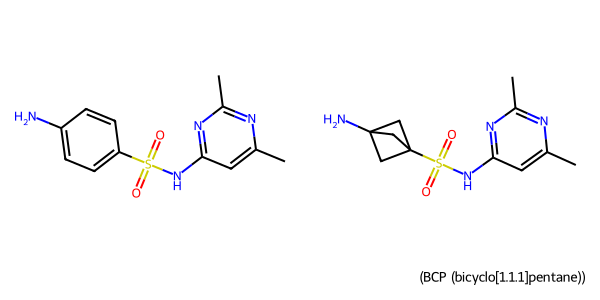

In [10]:
report_bcp = generate_full_report(
    "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1", "aniline", 1,
    client_qwen, "qwen3.8-max-preview", "openai_compatible"
)

원본:     CC(=O)OC(C)=O
치환 후:  CC(=O)O

[치환 근거 - 의약화학]
  규칙: beta-keto/anhydride -> carboxylic acid (anhydride hydrolyzed)
  산 무수물(R-C(=O)-O-C(=O)-R')은 강한 아실화제로 단백질 아미노산 잔기와 쉽게 반응하며, 수용액 환경에서 자발적으로 가수분해되어 두 개의 카르복실산으로 분해되는 것이 자연스러운 무독화 경로임. 한쪽 아실기를 제거하여 이 가수분해 최종형(카르복실산)으로 직접 전환 (검증 필요). ※ 대안 후보(무수물->아마이드/이미드 bioisostere) 는 문헌 확인 후 추가 예정

[정량 지표 - 활성 보존 근사]
  2D 연결성: 상이 (Tanimoto 0.417)
  3D 형태: 변화 (회전반경 -31.6%)
  약물유사성(QED): 변화 (+0.108)
  소수성(LogP): 유지 (-0.005)
  합성용이성(SA): 유지/개선 (-0.801)
  1차 판정: 3D 형태 자체가 크게 변화 — 표적 결합 형태 훼손 우려, 사람 검토 필요 [보조 경고: QED 변화]

[약리학 에이전트 최종 판단]
  1차 판정 동의: True
  코멘트: 3D 형태가 크게 감소했고 무수물에서 카르복시산으로 작용기 화학이 변해 표적 결합 모드나 반응성이 달라질 가능성이 있습니다. LogP와 SA가 유지/개선되었더라도 결합 활성 관점에서는 사람 검토가 필요합니다.
  사람 검토 필요: True


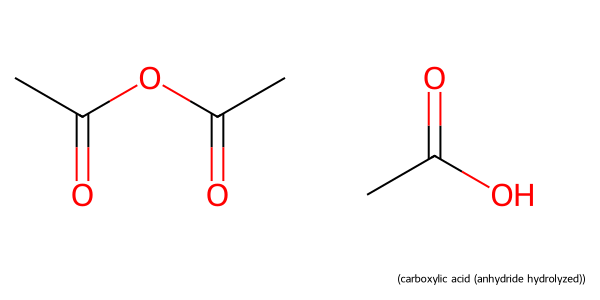

In [11]:
report_anh = generate_full_report(
    "CC(=O)OC(C)=O", "beta-keto/anhydride", 0,
    client_qwen, "qwen3.8-max-preview", "openai_compatible"
)

In [12]:
!git add -A
!git commit -m "Session 33: implement pharmacology agent (compute_activity_preservation_metrics + classify_activity_risk_v3 + LLM final judgment) that combines 2D Tanimoto, 3D shape (radius of gyration), QED, LogP, and SA Score into a human-readable activity-preservation report alongside the existing medicinal-chemistry rationale and structure images. Verified on contrasting cases: BCP ring-replacement (2D dissimilar but 3D shape preserved -> 'bioisostere, activity expected' with LogP/SA warnings) vs anhydride hydrolysis (3D shape itself collapses -> clear human-review flag). This gives researchers full context (rationale + quantitative metrics + visual structure) to make the final pharmacological call, per student/advisor feedback on activity preservation."
!git push origin main

[main c260727] Session 33: implement pharmacology agent (compute_activity_preservation_metrics + classify_activity_risk_v3 + LLM final judgment) that combines 2D Tanimoto, 3D shape (radius of gyration), QED, LogP, and SA Score into a human-readable activity-preservation report alongside the existing medicinal-chemistry rationale and structure images. Verified on contrasting cases: BCP ring-replacement (2D dissimilar but 3D shape preserved -> 'bioisostere, activity expected' with LogP/SA warnings) vs anhydride hydrolysis (3D shape itself collapses -> clear human-review flag). This gives researchers full context (rationale + quantitative metrics + visual structure) to make the final pharmacological call, per student/advisor feedback on activity preservation.
 2 files changed, 192 insertions(+)
 create mode 100644 fpscores.pkl.gz
 create mode 100644 sascorer.py
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 10

In [13]:
def ask_toxicology_agent(client, model_name, smiles, rule_name, client_type="openai_compatible"):
    """독성학 에이전트: 발견된 독성 구조가 실제로 얼마나 심각한 위험인지
    독립적으로 평가 (의약화학/약리학 판단과 분리된 첫 번째 의견)."""
    info = get_replacement_candidates(rule_name)
    rationale_sample = info['candidates'][0]['rationale'] if info else ""

    prompt = f"""당신은 독성학 전문가입니다. 다음 분자에서 발견된 구조적
위험을 평가해주세요.

분자: {smiles}
발견된 문제: {rule_name}
알려진 메커니즘: {rationale_sample}

이 구조가 실제로 얼마나 심각한 독성 위험을 나타내는지(1-5점, 5가 가장
심각), 그리고 왜 그렇게 판단했는지 답하세요.

{{"severity": 1-5 정수, "reasoning": "판단 근거 1-2문장"}}
"""
    text = _call_llm(client, model_name, prompt, client_type)
    fallback = {"severity": 3, "reasoning": "기본값(파싱 실패)"}
    return _parse_json_response(text, fallback)

print("독성학 에이전트 준비 완료")

독성학 에이전트 준비 완료


In [14]:
def coordinate_agents(client, model_name, original_smiles, rule_name, candidate_idx, client_type="openai_compatible"):
    """독성학 + 의약화학(기존 rationale) + 약리학 세 판단을 종합.
    약리학 에이전트가 human_review_needed=True면 다른 판단과 무관하게
    최종적으로 사람 검토를 요구한다(활성 손실이 가장 되돌리기 어려운
    실패이므로 거부권 부여)."""
    fixed = propose_fix(original_smiles, rule_name, candidate_idx)
    if fixed is None or not fixed.get('is_valid'):
        return {"final_decision": "치환 실패", "details": None}

    tox_judgment = ask_toxicology_agent(client, model_name, original_smiles, rule_name, client_type)

    metrics = compute_activity_preservation_metrics(original_smiles, fixed['new_smiles'])
    classification = classify_activity_risk_v3(metrics)
    pharm_judgment = ask_pharmacology_agent(client, model_name, original_smiles, fixed['new_smiles'],
                                              metrics, classification, client_type)

    # 조정 로직: 약리학 에이전트가 거부권
    if pharm_judgment['human_review_needed']:
        final_decision = "사람 검토 필요 (약리학 우려)"
    elif tox_judgment['severity'] <= 2:
        final_decision = "사람 검토 권장 (독성 심각도 낮음 — 치환 자체 재검토)"
    else:
        final_decision = "자동 승인 가능"

    return {
        "final_decision": final_decision,
        "toxicology": tox_judgment,
        "medchem_rationale": fixed['rationale'],
        "candidate_used": fixed['candidate_used'],
        "pharmacology": pharm_judgment,
        "metrics_classification": classification,
        "fixed_smiles": fixed['new_smiles'],
    }

print("조정자 준비 완료")

조정자 준비 완료


In [15]:
result_coordinated = coordinate_agents(
    client_qwen, "qwen3.8-max-preview",
    "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1", "aniline", 1,
    "openai_compatible"
)

print(f"최종 결정: {result_coordinated['final_decision']}")
print(f"\n[독성학] 심각도 {result_coordinated['toxicology']['severity']}/5")
print(f"  {result_coordinated['toxicology']['reasoning']}")
print(f"\n[의약화학] {result_coordinated['candidate_used']}")
print(f"  {result_coordinated['medchem_rationale'][:100]}...")
print(f"\n[약리학] {result_coordinated['pharmacology']['final_comment']}")

최종 결정: 사람 검토 필요 (약리학 우려)

[독성학] 심각도 2/5
  파라-아미노벤젠설폰아마이드 골격의 아닐린기는 이론적으로 N-hydroxylation/nitroso 대사체 가능성을 가지지만, 설파계 항생제에서 널리 사용된 안정적 구조로 예측 가능한 중증 독성은 낮습니다. 실제 위험은 드문 특이체질성 과민반응 수준으로 판단되어 경고는 참고 신호로 취급하는 것이 적절합니다.

[의약화학] BCP (bicyclo[1.1.1]pentane)
  para-이치환 아닐린의 방향족 벤젠 고리를 포화 bicyclic 탄소골격(BCP)으로 교체함. 방향족성 제거로 aniline reactive metabolite(RM) 형성 및 ...

[약리학] BCP 유사 치환은 3D 벡터를 보존해 결합 골격은 유지될 수 있으나, 아민 pKa·전자 분포 변화와 LogP 1.0 감소는 수소결합/소수성 상호작용 및 물성에 실질적 영향을 줄 수 있다. 따라서 활성 유지 기대는 조건부이며, 결합 포켓의 전하·소수성 맥락과 합성 난이도를 고려한 실험/계산 검증이 필요하다.


In [16]:
def coordinate_agents(client, model_name, original_smiles, rule_name, candidate_idx, client_type="openai_compatible"):
    """독성학 + 의약화학(기존 rationale) + 약리학 세 판단을 종합.
    - 독성 심각도 낮음 + 약리학 우려 = 치환 필요성 자체 재검토
    - 약리학 우려만 = 치환은 하되 결과를 사람이 검토
    - 독성 심각도만 낮음 = 원 진단 자체를 재검토 권장
    - 둘 다 문제 없음 = 자동 승인"""
    fixed = propose_fix(original_smiles, rule_name, candidate_idx)
    if fixed is None or not fixed.get('is_valid'):
        return {"final_decision": "치환 실패", "details": None}

    tox_judgment = ask_toxicology_agent(client, model_name, original_smiles, rule_name, client_type)

    metrics = compute_activity_preservation_metrics(original_smiles, fixed['new_smiles'])
    classification = classify_activity_risk_v3(metrics)
    pharm_judgment = ask_pharmacology_agent(client, model_name, original_smiles, fixed['new_smiles'],
                                              metrics, classification, client_type)

    low_severity = tox_judgment['severity'] <= 2
    pharm_concern = pharm_judgment['human_review_needed']

    if low_severity and pharm_concern:
        final_decision = "치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)"
    elif pharm_concern:
        final_decision = "사람 검토 필요 (약리학 우려)"
    elif low_severity:
        final_decision = "사람 검토 권장 (독성 심각도 낮음 — 치환 자체 재검토)"
    else:
        final_decision = "자동 승인 가능"

    return {
        "final_decision": final_decision,
        "toxicology": tox_judgment,
        "medchem_rationale": fixed['rationale'],
        "candidate_used": fixed['candidate_used'],
        "pharmacology": pharm_judgment,
        "metrics_classification": classification,
        "fixed_smiles": fixed['new_smiles'],
    }

print("조정자(v2) 준비 완료")

조정자(v2) 준비 완료


In [17]:
result_v2 = coordinate_agents(
    client_qwen, "qwen3.8-max-preview",
    "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1", "aniline", 1,
    "openai_compatible"
)

print(f"최종 결정: {result_v2['final_decision']}")
print(f"\n[독성학] 심각도 {result_v2['toxicology']['severity']}/5")
print(f"  {result_v2['toxicology']['reasoning']}")
print(f"\n[약리학] {result_v2['pharmacology']['final_comment']}")

최종 결정: 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)

[독성학] 심각도 2/5
  자유 1차 방향족 아민이 존재하지만 설파닐아마이드 유사 골격으로 임상적으로 널리 사용된 계열이며, 중증 독성보다는 드문 특이체질 반응 수준의 참고 신호에 가깝습니다. 다만 N-hydroxylation 가능성을 완전히 배제할 수 없어 완전 무위험(1점)보다는 낮은 주의가 필요합니다.

[약리학] 페닐기를 bicyclo[1.1.1]pentane 아민으로 대체한 것은 3D 형태와 결합 벡터를 보존하는 생등전자체 전략으로 타당하며, LogP 감소는 활성 유지 관점에서는 오히려 용해도 개선에 유리할 수 있습니다. 다만 아닐린성 아민이 지방족 1차 아민으로 바뀌어 pKa와 양성자화 상태, 수소결합 패턴이 달라지므로 표적 포켓 내 산성 잔기 또는 방향족 상호작용 의존성은 추가 검토가 필요합니다.


In [18]:
result_v2_anh = coordinate_agents(
    client_qwen, "qwen3.8-max-preview",
    "CC(=O)OC(C)=O", "beta-keto/anhydride", 0,
    "openai_compatible"
)

print(f"최종 결정: {result_v2_anh['final_decision']}")
print(f"\n[독성학] 심각도 {result_v2_anh['toxicology']['severity']}/5")
print(f"  {result_v2_anh['toxicology']['reasoning']}")
print(f"\n[약리학] {result_v2_anh['pharmacology']['final_comment']}")

최종 결정: 사람 검토 필요 (약리학 우려)

[독성학] 심각도 3/5
  아세트산 무수물은 강력한 아실화제로서 단백질 아미노산 잔기와 반응해 국소 자극·부식성을 보일 수 있습니다. 다만 수용액에서 빠르게 가수분해되어 아세트산으로 무독화되므로 전신 독성 위험은 제한적입니다.

[약리학] LogP 유지와 합성용이성 개선은 유리하지만, 무수물에서 카르복시산으로의 전환은 분자 크기·형태뿐 아니라 전하, 수소결합, 반응성을 크게 바꾸므로 표적 결합 활성이 훼손될 가능성이 높다. 3D 형태 급감과 낮은 2D 유사성을 고려하면 결합 포켓 문맥에서의 사람 검토가 필요하다.


In [19]:
!git add -A
!git commit -m "Extend coordinator with 3-way classification: toxicology severity + pharmacology concern jointly determine outcome. Low severity + pharm concern -> 're-examine whether substitution is even needed' (new category); high/mid severity + pharm concern -> 'human review needed'. Verified: BCP-aniline case (tox severity 2, pKa/protonation concern) correctly flagged as 'reconsider substitution necessity', while anhydride case (tox severity 3, charge/H-bond disruption concern) correctly flagged as 'human review needed'. Demonstrates 3-agent (toxicology/medchem/pharmacology) architecture producing differentiated, actionable guidance rather than a single binary flag."
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [20]:
verification_batch = []
for s in data['smiles_valid']:
    problems = detect_toxicophores(s)
    known = [p for p in problems if get_replacement_candidates(p['rule_name']) is not None]
    if not known:
        continue
    rule = known[0]['rule_name']
    verification_batch.append({"smiles": s, "rule": rule})
    if len(verification_batch) >= 30:  # LLM 호출 비용 고려해 30개로 축소
        break

print(f"배치 대상: {len(verification_batch)}개")

batch_results = []
for i, item in enumerate(verification_batch):
    result = coordinate_agents(client_qwen, "qwen3.8-max-preview", item['smiles'], item['rule'], 0, "openai_compatible")
    batch_results.append(result)
    print(f"[{i+1}/{len(verification_batch)}] {result['final_decision']}")

배치 대상: 30개
[1/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[2/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[3/30] 사람 검토 필요 (약리학 우려)
[4/30] 사람 검토 필요 (약리학 우려)
[5/30] 사람 검토 필요 (약리학 우려)
[6/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[7/30] 사람 검토 필요 (약리학 우려)
[8/30] 치환 실패
[9/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[10/30] 사람 검토 필요 (약리학 우려)
[11/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[12/30] 사람 검토 필요 (약리학 우려)
[13/30] 사람 검토 필요 (약리학 우려)
[14/30] 사람 검토 필요 (약리학 우려)
[15/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[16/30] 사람 검토 필요 (약리학 우려)
[17/30] 사람 검토 필요 (약리학 우려)
[18/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[19/30] 사람 검토 필요 (약리학 우려)
[20/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[21/30] 치환 실패
[22/30] 사람 검토 필요 (약리학 우려)
[23/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[24/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 우려 — 치환 필요성 자체를 재고)
[25/30] 치환 실패
[26/30] 사람 검토 필요 (약리학 우려)
[27/30] 치환 재검토 권장 (원 독성 위험 낮음 + 활성 영향 

In [21]:
import json
with open("batch_coordination_results.json", "w") as f:
    json.dump([{"final_decision": r["final_decision"]} for r in batch_results], f, ensure_ascii=False, indent=2)

!git add batch_coordination_results.json docs/
!git commit -m "Session 33 batch validation: 30-sample coordinator run (27 valid) - 44.4% flagged for substitution reconsideration (low toxicity + pharmacology concern), 55.6% flagged for human review (pharmacology concern), 0% auto-approved. Confirms conservative-by-design behavior: system consistently defers final activity-preservation judgment to human experts rather than auto-approving. Also add toxguard_roadmap.md documenting post-competition expansion plan (precedent library, docking validation, therapeutic-area specialization) for long-term portfolio use."
!git push origin main

[main 9bc8d6b] Session 33 batch validation: 30-sample coordinator run (27 valid) - 44.4% flagged for substitution reconsideration (low toxicity + pharmacology concern), 55.6% flagged for human review (pharmacology concern), 0% auto-approved. Confirms conservative-by-design behavior: system consistently defers final activity-preservation judgment to human experts rather than auto-approving. Also add toxguard_roadmap.md documenting post-competition expansion plan (precedent library, docking validation, therapeutic-area specialization) for long-term portfolio use.
 1 file changed, 92 insertions(+)
 create mode 100644 batch_coordination_results.json
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 833 bytes | 833.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.

In [22]:
reconsider_cases = [r for r in batch_results if "치환 재검토" in r.get('final_decision', '')]
review_cases = [r for r in batch_results if "약리학 우려" in r.get('final_decision', '')]
failed_cases = [r for r in batch_results if r.get('final_decision') == '치환 실패']

print(f"치환 재검토: {len(reconsider_cases)}개, 약리학우려: {len(review_cases)}개, 실패: {len(failed_cases)}개\n")

print("=== '치환 재검토 권장' 사례 2개 상세 ===\n")
for r in reconsider_cases[:2]:
    print(f"규칙: {r.get('candidate_used')}")
    print(f"독성학: 심각도 {r['toxicology']['severity']}/5 - {r['toxicology']['reasoning'][:100]}")
    print(f"약리학: {r['pharmacology']['final_comment'][:150]}")
    print(f"지표 요약: {r['metrics_classification']['verdict'][:100]}")
    print()

print("=== '사람 검토 필요(약리학 우려)' 사례 2개 상세 ===\n")
for r in review_cases[:2]:
    print(f"규칙: {r.get('candidate_used')}")
    print(f"독성학: 심각도 {r['toxicology']['severity']}/5 - {r['toxicology']['reasoning'][:100]}")
    print(f"약리학: {r['pharmacology']['final_comment'][:150]}")
    print(f"지표 요약: {r['metrics_classification']['verdict'][:100]}")
    print()

치환 재검토: 12개, 약리학우려: 15개, 실패: 3개

=== '치환 재검토 권장' 사례 2개 상세 ===

규칙: acetamide (acylated amine)
독성학: 심각도 2/5 - 파라-설폰아마이드 치환된 아닐린은 1차 방향족 아민으로서 N-하이드록실화/니트레늄 이온 형성 가능성이 있지만, 설폰아마이드 계열 약물에서 임상적으로 널리 사용되며 전자끌개 치환기가
약리학: 핵심 설폰아마이드-피리미딘 골격은 유지되나 말단 아닐린 NH2의 아세틸화는 3D 부피와 수소결합 패턴을 바꾸므로 결합 활성 영향을 단정할 수 없습니다. LogP/QED 변화는 경미하지만 말단 치환부가 포켓/용매 경계에 따라 효과가 달라질 수 있어 구조 기반 검토가 필요
지표 요약: 3D 형태 자체가 크게 변화 — 표적 결합 형태 훼손 우려, 사람 검토 필요

규칙: ketone/ester (one alkoxy removed, C=O formed)
독성학: 심각도 2/5 - 이 분자는 비고리 오르토폼에이트(HC(OR)3) 구조로 가수분해되기 쉽지만, 일반적으로 반응성 알데히드/케톤보다는 폼에이트/폼산과 프로판올로 전환되어 심각한 반응성 독성 위험은 낮
약리학: 치환은 tripropoxy orthoformate를 propyl formate로 크게 축약하여 두 개의 프로폭시 측쇄와 소수성 부피를 제거하므로, LogP -2와 회전반경 -42%는 표적 결합 형태와 친화도에 중대한 영향을 줄 가능성이 큽니다. 따라서 규칙 기반 판정에
지표 요약: 3D 형태 자체가 크게 변화 — 표적 결합 형태 훼손 우려, 사람 검토 필요 [보조 경고: QED 변화, LogP 변화]

=== '사람 검토 필요(약리학 우려)' 사례 2개 상세 ===

규칙: amide/amine (terminal N removed)
독성학: 심각도 4/5 - 말단 하이드라진/하이드라지드(-NH-NH2) 잔기는 대사적으로 반응성 디아제늄 또는 유사 중간체를 형성해 유전독성 가능성을 높이는 명확한 구조 경고입니다. 다만 아실 카보닐

In [23]:
!git add -A
!git commit -m "Deep-dive analysis of batch results: pharmacology agent frequently raises concerns even when quantitative shape/property metrics classify a case as 'preserved, activity likely maintained' - consistently citing H-bonding pattern, electronic distribution, or pKa changes not captured by our proxy metrics (Tanimoto, radius of gyration, QED, LogP, SA score). This demonstrates the LLM judgment layer meaningfully supplements rather than duplicates the rule-based metrics, catching chemically relevant concerns invisible to geometry/property-based scoring alone."
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [24]:
pattern_phthalimide = Chem.MolFromSmarts("O=C1c2ccccc2C(=O)N1[#6]")
test_phth = Chem.MolFromSmiles("O=C1c2ccccc2C(=O)N1CCCC")  # N-부틸프탈이미드 예시
print("phthalimide 매치:", test_phth.HasSubstructMatch(pattern_phthalimide))
matches_phth = test_phth.GetSubstructMatches(pattern_phthalimide)
print("매치 위치:", matches_phth)
for i, idx in enumerate(matches_phth[0]):
    print(f"  위치{i} -> idx{idx}: {test_phth.GetAtomWithIdx(idx).GetSymbol()}")

print()

pattern_hydroxamic = Chem.MolFromSmarts("C(=O)N[OX2H1]")
test_hydroxamic = Chem.MolFromSmiles("CC(=O)NO")  # 아세토하이드록삼산
print("hydroxamic_acid 매치:", test_hydroxamic.HasSubstructMatch(pattern_hydroxamic))
matches_hydrox = test_hydroxamic.GetSubstructMatches(pattern_hydroxamic)
print("매치 위치:", matches_hydrox)
for i, idx in enumerate(matches_hydrox[0]):
    print(f"  위치{i} -> idx{idx}: {test_hydroxamic.GetAtomWithIdx(idx).GetSymbol()}")

phthalimide 매치: True
매치 위치: ((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11),)
  위치0 -> idx0: O
  위치1 -> idx1: C
  위치2 -> idx2: C
  위치3 -> idx3: C
  위치4 -> idx4: C
  위치5 -> idx5: C
  위치6 -> idx6: C
  위치7 -> idx7: C
  위치8 -> idx8: C
  위치9 -> idx9: O
  위치10 -> idx10: N
  위치11 -> idx11: C

hydroxamic_acid 매치: True
매치 위치: ((1, 2, 3, 4),)
  위치0 -> idx1: C
  위치1 -> idx2: O
  위치2 -> idx3: N
  위치3 -> idx4: O


In [25]:
!cat src/tools/replacement_library.py


REPLACEMENT_LIBRARY = {
    "nitro_group": {
        "problem_smarts": "[N+](=O)[O-]",
        "candidates": [
            {"smiles": "N", "name": "primary amine",
             "rationale": "[참고] 메트로니다졸, 니트로푸란토인, 벤즈니다졸 등 일부 "
                          "항균제/항기생충제는 니트로기의 선택적 환원 활성화 자체가 "
                          "치료 메커니즘이므로, 이런 프로드러그 설계 맥락에서는 본 "
                          "치환이 적절하지 않을 수 있음. || 극성을 유지하면서 니트로기의 "
                          "환원성 대사 중간체 생성 경로를 제거함"},
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "약물유사 골격에서 흔히 쓰이는 안정적 대체기로, 수소결합 donor/acceptor 특성을 일부 유지"},
            {"smiles": "C#N", "name": "nitrile",
             "rationale": "대사 안정성이 개선된 사례가 문헌에 다수 보고됨, 다만 극성은 다소 감소"},
        ],
    },
    "aldehyde": {
        "problem_smarts": "[CX3H1](=O)",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "알데히드의 친전자성(단백질 부가물 형성 우려)을 제거하면서 유사한 형태 유지"},
            {"smiles": "C(O)", "name": "al

In [26]:
%%writefile src/tools/replacement_library.py

REPLACEMENT_LIBRARY = {
    "nitro_group": {
        "problem_smarts": "[N+](=O)[O-]",
        "candidates": [
            {"smiles": "N", "name": "primary amine",
             "rationale": "[참고] 메트로니다졸, 니트로푸란토인, 벤즈니다졸 등 일부 "
                          "항균제/항기생충제는 니트로기의 선택적 환원 활성화 자체가 "
                          "치료 메커니즘이므로, 이런 프로드러그 설계 맥락에서는 본 "
                          "치환이 적절하지 않을 수 있음. || 극성을 유지하면서 니트로기의 "
                          "환원성 대사 중간체 생성 경로를 제거함"},
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "약물유사 골격에서 흔히 쓰이는 안정적 대체기로, 수소결합 donor/acceptor 특성을 일부 유지"},
            {"smiles": "C#N", "name": "nitrile",
             "rationale": "대사 안정성이 개선된 사례가 문헌에 다수 보고됨, 다만 극성은 다소 감소"},
        ],
    },
    "aldehyde": {
        "problem_smarts": "[CX3H1](=O)",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "알데히드의 친전자성(단백질 부가물 형성 우려)을 제거하면서 유사한 형태 유지"},
            {"smiles": "C(O)", "name": "alcohol",
             "rationale": "가장 단순한 환원형 대체, 반응성 크게 감소"},
        ],
    },
    "Michael_acceptor_1": {
        "edit_method": "atom_edit",
        "problem_smarts": "C=CC(=O)",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "saturated (C-C single bond)",
             "rationale": "[참고] 에타크린산처럼 시스테인 잔기와의 공유결합 자체가 "
                          "작용 메커니즘인 공유결합 억제제(covalent inhibitor) "
                          "계열에는 본 경고가 그대로 적용되지 않을 수 있음. || "
                          "알파,베타-불포화 카르보닐의 C=C 이중결합을 환원하여 "
                          "단백질 친전자성 부가반응(Michael addition, covalent "
                          "binding) 위험을 제거함"},
        ],
    },
    "acid_halide": {
        "problem_smarts": "C(=O)[F,Cl,Br,I]",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "고반응성 아실할라이드를 안정적인 아마이드로 대체"},
            {"smiles": "C(=O)O", "name": "ester",
             "rationale": "아마이드보다 극성이 낮고 유연한 대체 옵션, 가수분해 속도 조절 가능 (검증 필요)"},
        ],
    },
    "alkyl_halide": {
        "problem_smarts": "[Cl,Br,I]",
        "candidates": [
            {"smiles": "O", "name": "hydroxyl (alcohol)",
             "rationale": "[참고] 메클로르에타민, 사이클로포스파미드, 카머스틴, "
                          "클로람부실 등 알킬화 항암제는 DNA 알킬화(반응성) 자체가 "
                          "세포독성 치료 메커니즘이므로, 이 계열에는 본 치환이 "
                          "적절하지 않음. || 이탈기를 제거해 알킬화 반응성을 없앰, "
                          "극성은 유사하게 유지"},
            {"smiles": "F", "name": "fluorine",
             "rationale": "할로겐을 유지하되 C-F 결합은 강해 이탈기로 작용하지 않음, 입체적 크기도 유사"},
        ],
    },
    "aniline": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NH2]c1ccc([#6,#7,#8,#16])cc1",
        "target_idx_in_pattern": 0,
        "ring_atom_indices_in_pattern": [1, 2, 3, 4, 6, 7],
        "anchor_indices_in_pattern": (0, 5),
        "candidates": [
            {"edit_type": "add_substituent", "param": "C(=O)C",
             "target_idx_in_pattern": 0,
             "name": "acetamide (acylated amine)",
             "rationale": "[참고] 설파계 항생제(설파닐아마이드, 설파메톡사졸 등)와 "
                          "프로카인아마이드처럼 아닐린 골격이 반응성 대사가 아닌 "
                          "안정적 형태로 널리 처방되어 온 사례가 다수 있음. 이 경우 "
                          "특이체질 반응은 드물고 예측이 어려워, 본 경고를 절대적 "
                          "배제 기준이 아닌 참고 신호로 해석해야 함. || 1차 방향족 "
                          "아민을 아마이드로 아실화하여 N-hydroxylation 경로 자체를 차단"},
            {"edit_type": "replace_ring", "param": "[*:1]C12CC(C1)(C2)[*:2]",
             "ring_atom_indices_in_pattern": [1, 2, 3, 4, 6, 7],
             "anchor_indices_in_pattern": (0, 5),
             "name": "BCP (bicyclo[1.1.1]pentane)",
             "rationale": "para-이치환 아닐린의 방향족 벤젠 고리를 포화 bicyclic "
                          "탄소골격(BCP)으로 교체함. 방향족성 제거로 aniline reactive "
                          "metabolite(RM) 형성 및 CYP-inhibition을 감소시켜, 퀴논이민 "
                          "생성 경로를 차단하고 특이체질 약물 부작용(IADR) 위험을 낮춤 "
                          "(문헌 근거, 학생 제공). 벤젠과의 공간적 유사성, Fsp3 증가, "
                          "실제 성공 사례가 많아 채택. 아마이드화(단순 아민 치환)보다 "
                          "변화 폭이 크지만, 물성 개선 효과도 더 큼"},
        ],
    },
    "Sulfonic_acid_2": {
        "problem_smarts": "[#6]S(=O)(=O)[OX2H1,OX1-]",
        "candidates": [
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "[참고] 암페타민 설페이트, 사퀴나비르 메실레이트처럼 "
                          "일부 승인약물에서 설폰산/설폰산 유사기는 활성 골격이 "
                          "아니라 염(salt) 형성을 위한 카운터이온으로만 존재함. "
                          "이 경우 본 규칙이 다루는 '독성 유발 골격'과 무관하므로, "
                          "치환 대상 여부를 판단하기 전에 이 산이 활성 골격의 "
                          "일부인지 염 형성용인지 구분이 필요함. || 생리적 pH에서 "
                          "이온화 정도(전하)를 크게 낮춰 세포막 투과성을 개선함. "
                          "설폰산은 대부분 음이온 상태로 존재해 경구 흡수가 저해되는 "
                          "경우가 많으나, 설폰아마이드는 유사한 골격을 유지하면서도 "
                          "중성에 가까워 약물유사성이 개선됨"},
            {"smiles": "C(=O)O", "name": "carboxylic acid",
             "rationale": "설폰산보다 산성도가 약하고 부피가 작은 산성 bioisostere "
                          "(검증 필요)"},
        ],
    },
    "imine_1_oxime": {
        "edit_method": "atom_edit",
        "problem_smarts": "C=N[OX2H1]",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "amine (reduced)",
             "rationale": "옥심의 C=N 결합을 환원하여, 가수분해 시 원래의 반응성 "
                          "카르보닐(알데히드/케톤)로 되돌아갈 수 있는 대사 불안정 "
                          "경로를 제거함"},
        ],
    },
    "imine_1_general": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX3;!$(C(N)(N)=N)]=N",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "amine (reduced)",
             "rationale": "일반 이민(C=N-R)을 환원하여 가수분해 시 반응성 카르보닐로 "
                          "되돌아갈 수 있는 대사 불안정 경로를 제거함. 옥심 특유의 "
                          "메커니즘보다는 근거가 다소 약하며, 하위 구조별 개별 검증 필요. "
                          "구아니딘(N-C(=N)-N, 공명구조로 일반 이민과 반응성이 다름)은 "
                          "이 SMARTS에서 명시적으로 제외함"},
        ],
    },
    "catechol": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2H;$(Oc1ccccc1O)]",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "add_substituent", "param": "C", "name": "methoxy",
             "rationale": "[참고] 도파민, 에피네프린, 이소프로테레놀 등 카테콜아민류 "
                      "약물은 카테콜 구조 자체가 아드레날린/도파민 수용체 결합에 "
                      "필수적인 약효 골격이므로, 이 경우 본 치환은 독성 감소가 "
                      "아니라 약효 상실로 이어짐. 실제 도파민은 도파민 수용체 "
                      "D1(Ki 4.3-5.6 nM), D2(Ki 4.7-7.2 nM), D3(Ki 6.4-7.3 nM)에 "
                      "단자릿수 나노몰 수준의 강력한 작용제 친화도를 가짐(IUPHAR/BPS "
                      "Guide to PHARMACOLOGY 확인). || 인체의 COMT(catechol-O-"
                      "methyltransferase) 효소가 카테콜을 메톡시페놀로 메틸화하여 "
                      "해독하는 생리적 경로와 동일한 원리. 오르토-퀴논으로의 산화 "
                      "경로를 차단하여 세포독성/유전독성 우려를 낮춤 (학생 확인 "
                      "예정: ScienceDirect catechol overview, PMC6643002 등 참고)"},
         ],
    },
    "Thiocarbonyl_group": {
        "edit_method": "atom_edit",
        "problem_smarts": "[#6]=[#16]",
        "target_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "carbonyl (O replacing S)",
             "rationale": "[참고] 티오펜탈·티아밀랄(치오바르비투레이트, C=S가 지용성 "
                          "증가로 빠른 마취효과에 기여)과 티오구아닌(퓨린 유사 항대사물, "
                          "황이 작용기전에 필수)처럼 황 원자가 약효/효력에 직접 "
                          "기여하는 경우가 있어, 이 계열에는 본 치환이 부적절할 수 "
                          "있음. || 황을 산소로 대체(티오카르보닐->카르보닐)하는 것은 "
                          "흔한 bioisostere 전략으로, 갑상선 기능 저해 등 황 함유 "
                          "작용기 특유의 대사/독성 우려를 낮춤 (검증 필요, "
                          "thiourea->urea 치환 논리와 동일 계열)"},
        ],
    },
    "thiol_2": {
        "problem_smarts": "[SX2H1]",
        "candidates": [
            {"smiles": "O", "name": "hydroxyl (alcohol)",
             "rationale": "티올의 금속 킬레이팅 및 산화(이황화물/술펜산 형성) 반응성을 "
                          "제거하면서, 극성·수소결합 특성을 유사하게 유지함"},
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "티올을 아마이드로 대체하여 반응성을 낮추면서 약물유사 골격에서 "
                          "흔히 쓰이는 안정적 작용기로 전환 (검증 필요)"},
        ],
    },
    "thiol_1_dithiocarbamate": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=S)[SX1-]",
        "candidates": [
            {"edit_type": "replace_multi",
             "param": [
                 {"idx_in_pattern": 1, "new_element": 8, "new_charge": 0},
                 {"idx_in_pattern": 2, "new_element": 7, "new_charge": 0},
             ],
             "name": "carbamate (O,N replacing S,S)",
             "rationale": "디티오카바메이트(R-O-C(=S)-S-)를 카바메이트(R-O-C(=O)-N)로 "
                          "전환. 두 황 원자를 각각 산소·질소로 교체하여 금속 킬레이팅 "
                          "능력과 효소 억제 활성(디티오카바메이트류 특유의 살충제성 "
                          "독성 기전)을 제거함 (검증 필요)"},
        ],
    },
    "thiol_1_thiocarboxylate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX1-]C(=O)",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "carboxylate (O replacing S)",
             "rationale": "티오카르복실산 음이온(R-C(=O)-S-)의 황을 산소로 대체하여 "
                          "카르복실산염(R-C(=O)-O-)으로 전환. 황 원자의 금속 킬레이팅 "
                          "및 친핵성 반응성을 제거함 (검증 필요)"},
        ],
    },
    "het-C-het_not_in_ring": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX4](O)(O)",
        "candidates": [
            {"edit_type": "remove_substituent",
             "center_idx_in_pattern": 0,
             "remove_idx_in_pattern": 1,
             "upgrade_bond_to_idx_in_pattern": 2,
             "name": "ketone/ester (one alkoxy removed, C=O formed)",
             "rationale": "아세탈/케탈 또는 오르토에스터(탄소 하나에 알콕시기 2개 "
                          "이상)는 가수분해에 민감하여 반응성 카르보닐(케톤/알데히드)로 "
                          "쉽게 분해되며 대사 불안정성을 일으킴. 알콕시기 하나를 제거하고 "
                          "남은 산소를 카르보닐로 승격시켜, 가수분해로 어차피 도달할 "
                          "안정한 최종 형태로 미리 전환함 (검증 필요)"},
        ],
    },
    "hydroquinone": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2H]c1ccc([OX2H,NX3H1,NX3H2])cc1",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "add_substituent", "param": "C", "name": "methoxy",
             "rationale": "[참고] 아세트아미노펜은 정상 용량에서는 안전하며 과다복용 "
                          "시에만 위험한 용량 의존적 사례임. 본 시스템은 치료지수를 "
                          "고려하지 않으므로, 아트로핀·디곡신·와파린처럼 좁은 치료지수를 "
                          "가진 기존 약물 전반에 유사하게 적용되는 한계임. || 파라 "
                          "위치에 OH와 (OH 또는 NH)가 있는 구조(하이드로퀴논/파라-"
                          "아미노페놀 계열)는 산화되어 파라-퀴논 또는 파라-퀴논이민(예: "
                          "아세트아미노펜의 NAPQI)을 형성, 글루타치온 고갈과 단백질 "
                          "공유결합을 통한 간독성 위험이 있음"},
        ],
    },
    "azo_A(324)": {
        "edit_method": "atom_edit",
        "problem_smarts": "N=N",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "hydrazine (reduced)",
             "rationale": "아조기(N=N)는 체내에서 아조환원효소에 의해 환원되어 두 개의 "
                          "방향족 아민으로 분해되며, 그 중 일부(벤지딘류 등)가 발암성을 "
                          "가지는 것으로 잘 알려짐(아조 색소의 대표적 독성 메커니즘). "
                          "이중결합을 환원하여 하이드라진 형태로 전환, 완전한 아민 "
                          "분해 경로 자체를 차단함 (검증 필요: 하이드라진 자체의 "
                          "잔여 반응성은 추가 확인 필요)"},
        ],
    },
    "Three-membered_heterocycle": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX4]1[OX2][CX4]1",
        "candidates": [
            {"edit_type": "open_epoxide", "break_pair_in_pattern": (1, 2),
             "name": "vicinal diol (ring-opened)",
             "rationale": "에폭시드(3원자 고리, 옥시란)는 고리 변형(strain)으로 인해 "
                          "친핵체(DNA, 단백질)와 쉽게 반응하는 알킬화제로 작용함. "
                          "체내 에폭시드 가수분해효소(epoxide hydrolase)가 실제로 "
                          "수행하는 반응과 동일하게 고리를 열어 비시날 디올(vicinal "
                          "diol)로 전환, 반응성을 제거함"},
        ],
    },
    "diketo_group": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)C(=O)",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "alpha-hydroxy ketone (reduced)",
             "rationale": "비시날 알파-디케톤(1,2-diketone)은 반응성이 높은 친전자체로 "
                          "단백질과 부가물을 형성할 수 있으며, 흡입 시 호흡기 독성을 "
                          "일으키는 것으로 알려진 디아세틸(버터향 첨가제) 사례가 대표적임. "
                          "카르보닐 하나를 환원하여 알파-하이드록시케톤(아실로인)으로 "
                          "전환, 케토-환원효소에 의한 실제 해독 경로와 유사한 방향으로 "
                          "반응성을 낮춤 (검증 필요)"},
        ],
    },
    "thioester": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX2](C(=O))",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "ester (O replacing S)",
             "rationale": "티오에스터의 황을 산소로 대체하여 일반 에스터로 전환. "
                          "티오에스터는 일반 에스터보다 가수분해 반응성이 높고 아실화 "
                          "능력이 강해 단백질 등과 부반응 우려가 있음 (검증 필요)"},
        ],
    },
    "N-nitroso": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX2;+0;!$(N(=O)[O-])]=[OX1;+0]",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "N-hydroxylamine (reduced)",
             "rationale": "N-니트로소 화합물(니트로사민)은 대사 활성화(알파-수산화)를 "
                          "거쳐 강력한 알킬화 발암물질을 생성하는 것으로 잘 알려짐 "
                          "(발사르탄, 라니티딘 등 실제 의약품 불순물 리콜 사례). "
                          "N=O를 환원하여 반응성을 낮춤 (검증 필요: 완전한 해독은 "
                          "탈니트로소화가 필요하며 이는 근사적 접근)"},
        ],
    },
    "hydrazine": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX3H2][NX3H1]",
        "center_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 0,
             "center_idx_in_pattern": 1,
             "name": "amide/amine (terminal N removed)",
             "rationale": "하이드라진/하이드라지드(R-NH-NH2)의 말단 질소를 제거하여 "
                          "단순 아민 또는 아마이드로 되돌림. 하이드라진류는 대사 시 "
                          "반응성 디아제늄 중간체를 형성해 유전독성을 일으킬 수 있는 "
                          "것으로 알려짐. 이는 azo_A(324) 환원 시 생성되는 하이드라진 "
                          "중간체의 잔여 위험을 추가로 낮추는 후속 규칙이기도 함 "
                          "(검증 필요)"},
        ],
    },
    "sulphate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2][SX4](=O)(=O)[OX1,OX2H]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "alcohol (sulfate group removed)",
             "rationale": "알킬 설페이트 에스터(R-O-SO3-)는 대사되어 반응성 있는 "
                          "설페이트 이탈기를 통한 알킬화제로 작용할 수 있음(디메틸설페이트가 "
                          "강력한 발암/독성 물질로 잘 알려진 대표 사례). 설페이트기 전체를 "
                          "제거하여 원래의 알코올로 되돌림 (검증 필요)"},
        ],
    },
    "N_oxide": {
        "edit_method": "atom_edit",
        "problem_smarts": "[n+][O-]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "pyridine (N-oxide removed)",
             "rationale": "방향족 N-옥사이드는 산화적 대사산물이자 반응성 중간체 "
                          "생성 경로의 일부일 수 있음. 산소를 제거하여 원래의 중성 "
                          "방향족 아민(피리딘 등)으로 환원, 자연 대사에서의 환원 "
                          "경로와 유사한 방향으로 반응성을 낮춤 (검증 필요)"},
        ],
    },
    "2-halo_pyridine": {
        "edit_method": "atom_edit",
        "problem_smarts": "n:c(-[Cl,Br,I])",
        "center_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 2,
             "center_idx_in_pattern": 1,
             "name": "pyridine (halogen removed)",
             "rationale": "피리딘 고리 질소에 인접한 위치의 할로겐(특히 불소/염소)은 "
                          "친핵성 방향족 치환(SNAr) 반응에 취약해, 체내 친핵체(글루타치온, "
                          "단백질 시스테인 등)와 반응할 수 있음. 할로겐을 제거하고 수소로 "
                          "대체하여 이 반응성 경로를 차단함 (검증 필요)"},
        ],
    },
    "disulphide": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX2][SX2]",
        "candidates": [
            {"edit_type": "cleave_bond", "cleave_pair_in_pattern": (0, 1),
             "name": "two thiols (bond cleaved)",
             "rationale": "[참고] 이황화결합(S-S)은 시스틴/단백질의 3차구조 형성에 "
                          "필수적인 정상 생체 구조이기도 하므로, 이 결합이 약물의 "
                          "구조 안정성이나 표적 결합에 관여하는 경우 본 치환이 "
                          "부적절할 수 있음. || 디티오카바메이트류(티우람 등) 농약/"
                          "살균제에서 흔한 반응성 이황화결합을 두 개의 티올로 분리, "
                          "산화·금속킬레이팅 반응성을 낮춤 (검증 필요)"},
        ],
    },
    "quinone_A(370)": {
        "edit_method": "atom_edit",
        "problem_smarts": "O=C1C=CC(=O)C=C1",
        "target_pairs_in_pattern": [(1, 0), (4, 5)],
        "ring_atoms_in_pattern": [1, 2, 3, 4, 6, 7],
        "ring_bonds_in_pattern": [(1, 2), (2, 3), (3, 4), (4, 6), (6, 7), (7, 1)],
        "candidates": [
            {"edit_type": "reduce_multi_bond", "name": "hydroquinone (reduced, re-aromatized)",
             "rationale": "파라벤조퀴논은 산화환원 사이클(redox cycling)을 통해 활성산소종(ROS)을 "
                          "생성하고 DNA/단백질과 직접 공유결합하는 대표적 반응성 구조. 체내 "
                          "NQO1(퀴논 환원효소) 효소가 실제로 수행하는 반응과 동일하게 두 카르보닐을 "
                          "환원하고 고리를 재방향족화하여 안정적인 하이드로퀴논으로 전환. 결과물이 "
                          "다시 hydroquinone 규칙에 해당할 수 있으며, 이 경우 반복 루프가 자동으로 "
                          "메톡시페놀 등 산화에 더 안정적인 형태로 한 단계 더 개선함 (검증 필요, "
                          "안트라퀴논 등 융합고리형은 미지원)"},
        ],
    },
    "quinone_A_anthraquinone": {
        "edit_method": "atom_edit",
        "problem_smarts": "O=C1c2ccccc2C(=O)c2ccccc21",
        "target_pairs_in_pattern": [(1, 0), (8, 9)],
        "ring_atoms_in_pattern": [1, 2, 3, 4, 5, 6, 7, 8],
        "ring_bonds_in_pattern": [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 1)],
        "candidates": [
            {"edit_type": "reduce_multi_bond", "name": "anthrahydroquinone (reduced, re-aromatized)",
             "rationale": "안트라퀴논은 벤조퀴논과 동일한 산화환원 사이클링(redox cycling) 메커니즘을 "
                          "가지되, 두 벤젠 고리에 의해 안정화되어 항암제(독소루비신 등) 및 염료에서도 "
                          "흔히 쓰이는 골격임. 두 카르보닐을 동시에 환원하고 중앙 고리를 재방향족화하여 "
                          "안트라하이드로퀴논으로 전환, 산화환원 사이클링 능력을 제거함. 결과물이 "
                          "hydroquinone 규칙에 해당할 수 있어 반복 루프가 자동으로 추가 개선 가능 "
                          "(Murcko scaffold 분석으로 발견, 검증 필요)"},
        ],
    },
    "quinone_diimine": {
        "edit_method": "atom_edit",
        "problem_smarts": "N=C1C=CC(=N)C=C1",
        "target_pairs_in_pattern": [(1, 0), (4, 5)],
        "ring_atoms_in_pattern": [1, 2, 3, 4, 6, 7],
        "ring_bonds_in_pattern": [(1, 2), (2, 3), (3, 4), (4, 6), (6, 7), (7, 1)],
        "candidates": [
            {"edit_type": "reduce_multi_bond", "name": "phenylenediamine (reduced, re-aromatized)",
             "rationale": "퀴논디이민(quinone diimine)은 벤조퀴논의 산소가 이민으로 치환된 유사체로, "
                          "동일한 산화환원 사이클링 메커니즘을 가지며 헤어염료 성분(파라페닐렌디아민 "
                          "산화형) 등에서 피부 알레르기 및 접촉성 피부염을 유발하는 것으로 알려짐. 두 "
                          "이민을 동시에 환원하고 고리를 재방향족화하여 페닐렌디아민(원래의 안정한 "
                          "환원형)으로 전환 (Murcko scaffold 분석으로 발견, 검증 필요)"},
        ],
    },
    "isocyanate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX2]=[CX2]=[OX1]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "amine (NCO hydrolyzed)",
             "rationale": "이소시아네이트(R-N=C=O)는 매우 반응성이 높은 친전자체로, "
                          "단백질/아미노기와 쉽게 부가반응을 일으켜 직업성 천식·과민증을 "
                          "유발하는 것으로 잘 알려짐(TDI, MDI 등 산업용 이소시아네이트 "
                          "사례). 체내/환경에서 실제로 일어나는 가수분해 경로(R-NCO + H2O "
                          "-> R-NH2 + CO2)와 동일하게 카르보닐 탄소와 산소를 제거하고 "
                          "질소만 남겨 아민으로 전환 (검증 필요)"},
        ],
    },
    "triple_bond": {
        "problem_smarts": "C#C",
        "edit_method": "atom_edit",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "alkene (partially reduced)",
             "rationale": "말단 알카인(삼중결합)은 CYP450 효소에 의해 기계기반 억제"
                          "(mechanism-based inhibition) 경로로 대사되며, 반응성 케텐/"
                          "에폭사이드 중간체를 형성해 효소를 비가역적으로 불활성화할 "
                          "수 있음(에티닐에스트라디올 등에서 알려진 메커니즘). 삼중결합을 "
                          "이중결합으로 환원하여 반응성을 낮춤 (검증 필요, 완전 포화가 "
                          "아닌 부분 환원)"},
        ],
    },
    "stilbene": {
        "problem_smarts": "c-[CX3]=[CX3]-c",
        "edit_method": "atom_edit",
        "target_idx_pair_in_pattern": (1, 2),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "diarylethane (reduced)",
             "rationale": "스틸벤 구조(두 방향족 고리를 잇는 C=C)는 디에틸스틸베스트롤"
                          "(DES)처럼 내분비교란 및 대사 산화를 통한 반응성 중간체 형성이 "
                          "알려진 골격. 이중결합을 환원하여 평면성을 낮추고 대사 반응성을 "
                          "완화함 (검증 필요, 에스트로겐 수용체 결합에 필요한 형태 자체를 "
                          "훼손할 수 있어 신중한 해석 필요)"},
        ],
    },
    "beta-keto/anhydride": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)OC(=O)",
        "center_idx_in_pattern": 2,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 3,
             "center_idx_in_pattern": 2,
             "name": "carboxylic acid (anhydride hydrolyzed)",
             "rationale": "산 무수물(R-C(=O)-O-C(=O)-R')은 강한 아실화제로 단백질 아미노산 "
                          "잔기와 쉽게 반응하며, 수용액 환경에서 자발적으로 가수분해되어 "
                          "두 개의 카르복실산으로 분해되는 것이 자연스러운 무독화 경로임. "
                          "한쪽 아실기를 제거하여 이 가수분해 최종형(카르복실산)으로 직접 "
                          "전환 (검증 필요). ※ 대안 후보(무수물->아마이드/이미드 bioisostere) "
                          "는 문헌 확인 후 추가 예정"},
        ],
    },
    "phthalimide": {
        "edit_method": "atom_edit",
        "problem_smarts": "O=C1c2ccccc2C(=O)N1[#6]",
        "center_idx_in_pattern": 10,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 10,
             "name": "primary amine (imide hydrolyzed)",
             "rationale": "프탈이미드(고리형 이미드)는 탈리도마이드 등에서 알려진 골격으로, "
                          "체내에서 가수분해되어 원래의 1차 아민과 프탈산으로 분해되는 것이 "
                          "자연스러운 대사 경로임. 이 가수분해 용이성 자체가 대사 불안정성/"
                          "반응성 우려의 근거이며, 고리 전체를 제거하여 이 가수분해 최종형인 "
                          "1차 아민으로 직접 전환 (검증 필요)"},
        ],
    },
    "hydroxamic_acid": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)N[OX2H1]",
        "center_idx_in_pattern": 2,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 3,
             "center_idx_in_pattern": 2,
             "name": "amide (N-hydroxyl removed)",
             "rationale": "[참고] 하이드록삼산(R-C(=O)-NH-OH)은 보리노스타트, 파노비노스타트 "
                          "등 HDAC 억제제에서 아연 킬레이션을 통한 핵심 약효 작용기로 쓰이므로, "
                          "이 계열에는 본 치환이 약효 상실로 이어질 수 있음. || 하이드록삼산은 "
                          "로센 재배열(Lossen rearrangement)을 통해 반응성 이소시아네이트로 "
                          "전환될 수 있는 잠재적 위험이 있음. N-하이드록실기를 제거해 단순 "
                          "아마이드로 전환, 이 재배열 경로를 차단함 (검증 필요)"},
        ],
    },
}

def get_replacement_candidates(rule_name: str) -> dict | None:
    """rule_name에 해당하는 치환 정보(SMARTS + 후보 리스트)를 반환. 없으면 None."""
    return REPLACEMENT_LIBRARY.get(rule_name)


Overwriting src/tools/replacement_library.py


In [27]:
importlib.reload(src.tools.replacement_library)
importlib.reload(src.tools.atom_editor)
importlib.reload(src.tools.molecule_editor)
from src.tools.molecule_editor import propose_fix

print("phthalimide:", propose_fix("O=C1c2ccccc2C(=O)N1CCCC", "phthalimide", candidate_idx=0))
print("hydroxamic_acid:", propose_fix("CC(=O)NO", "hydroxamic_acid", candidate_idx=0))

print("\n=== 회귀 테스트 ===")
print(propose_fix("CC(=O)OC(C)=O", "beta-keto/anhydride", candidate_idx=0))

phthalimide: {'new_smiles': 'CCCCN', 'candidate_used': 'primary amine (imide hydrolyzed)', 'rationale': '프탈이미드(고리형 이미드)는 탈리도마이드 등에서 알려진 골격으로, 체내에서 가수분해되어 원래의 1차 아민과 프탈산으로 분해되는 것이 자연스러운 대사 경로임. 이 가수분해 용이성 자체가 대사 불안정성/반응성 우려의 근거이며, 고리 전체를 제거하여 이 가수분해 최종형인 1차 아민으로 직접 전환 (검증 필요)', 'is_valid': True}
hydroxamic_acid: {'new_smiles': 'CC(N)=O', 'candidate_used': 'amide (N-hydroxyl removed)', 'rationale': '[참고] 하이드록삼산(R-C(=O)-NH-OH)은 보리노스타트, 파노비노스타트 등 HDAC 억제제에서 아연 킬레이션을 통한 핵심 약효 작용기로 쓰이므로, 이 계열에는 본 치환이 약효 상실로 이어질 수 있음. || 하이드록삼산은 로센 재배열(Lossen rearrangement)을 통해 반응성 이소시아네이트로 전환될 수 있는 잠재적 위험이 있음. N-하이드록실기를 제거해 단순 아마이드로 전환, 이 재배열 경로를 차단함 (검증 필요)', 'is_valid': True}

=== 회귀 테스트 ===
{'new_smiles': 'CC(=O)O', 'candidate_used': 'carboxylic acid (anhydride hydrolyzed)', 'rationale': "산 무수물(R-C(=O)-O-C(=O)-R')은 강한 아실화제로 단백질 아미노산 잔기와 쉽게 반응하며, 수용액 환경에서 자발적으로 가수분해되어 두 개의 카르복실산으로 분해되는 것이 자연스러운 무독화 경로임. 한쪽 아실기를 제거하여 이 가수분해 최종형(카르복실산)으로 직접 전환 (검증 필요). ※ 대안 후보(무수물->아마이드/이미드 bioisostere) 는 문헌 확인 후 추가 예정", 'is

In [28]:
!git add src/tools/replacement_library.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   src/tools/replacement_library.py



In [29]:
!git commit -m "Add phthalimide (cyclic imide -> primary amine via remove_atom, mirrors real hydrolysis pathway to amine + phthalic acid, thalidomide-related scaffold) and hydroxamic_acid (N-hydroxyl removed -> amide via remove_atom, blocks Lossen rearrangement to reactive isocyanate; [참고] caution for HDAC inhibitors like vorinostat where hydroxamic acid is the essential zinc-chelating pharmacophore). Library now 34 rules."
!git push origin main

[main d1560be] Add phthalimide (cyclic imide -> primary amine via remove_atom, mirrors real hydrolysis pathway to amine + phthalic acid, thalidomide-related scaffold) and hydroxamic_acid (N-hydroxyl removed -> amide via remove_atom, blocks Lossen rearrangement to reactive isocyanate; [참고] caution for HDAC inhibitors like vorinostat where hydroxamic acid is the essential zinc-chelating pharmacophore). Library now 34 rules.
 1 file changed, 33 insertions(+)
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 1.33 KiB | 1.33 MiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Dec32th/laidd-2026.git
   9bc8d6b..d1560be  main -> main


In [30]:
count_final_v34 = 0
for s in data['smiles_valid']:
    p = detect_toxicophores(s)
    known_count = sum(1 for x in p if get_replacement_candidates(x['rule_name']) is not None)
    if known_count >= 1:
        count_final_v34 += 1

print(f"Valid set 커버리지 (34개 규칙): {count_final_v34}개 / {len(data['smiles_valid'])}개 ({count_final_v34/len(data['smiles_valid'])*100:.1f}%)")

Valid set 커버리지 (34개 규칙): 390개 / 1173개 (33.2%)


In [31]:
%%writefile README.md
# AI 기반 신약 후보물질 독성 최적화 에이전트

제4회 AI 신약개발 경진대회(JUMP AI 2026) 참가 프로젝트이며, 동시에
2026년 한 해 동안 진행하는 LAIDD 학습 기록을 담은 리포지토리입니다.

## 무엇을 하는 프로젝트인가

RDKit과 Tox21/Ames/hERG/DILI 데이터를 활용해, 독성이 우려되는 화합물을
**예측 → 구조 진단 → 치환 판단(LLM) → 구조 개선 → 활성 보존 검토 →
재평가**하는 과정을 자동으로 반복하는 에이전틱 최적화 루프를 만듭니다.

1. Tox21/Ames/hERG/DILI 기반 모델로 화합물의 독성 예측
2. RDKit FilterCatalog로 문제 구조(toxicophore)를 탐지
3. LLM 에이전트가 (여러 문제 중) 무엇을 먼저 고칠지, (여러 후보 중) 어떤
   치환이 화학적으로 타당한지 판단 — 단, 실제 구조 변경은 RDKit 기반
   결정적 도구가 전담(LLM은 화학구조를 직접 생성하지 않음)
4. 3개 전문가 에이전트(독성학/의약화학/약리학)가 정량 지표(Tanimoto,
   3D 형태, QED, LogP, SA Score)를 근거로 활성 보존 가능성을 함께 검토,
   불확실한 경우 사람 검토를 명시적으로 요청
5. 개선된 구조를 다시 예측 모델에 넣어 독성이 실제로 줄었는지 확인,
   문제가 남으면 반복

## 현재 상태 (2026-08 기준)

- 치환 라이브러리 34개 규칙, 11가지 구조 편집 방식
- Held-out(valid set) 커버리지 33.2%, 단일 문제 분자 기준 최소 1단계
  이상 개선 84%
- 4개 독립 독성 endpoint(Tox21/Ames/hERG/DILI) 교차검증
- 3-에이전트(독성학/의약화학/약리학) 판단 + 활성보존 근사지표 통합
- 개발 과정에서 발견한 이름 불일치·중복 규칙·재시도 로직 결함 등의
  오류를 전수검사 및 ablation 실험으로 스스로 발견·수정 (자세한 내용은
  `docs/limitations.md` 참고)

## 폴더 구조

- `src/tools/` — 핵심 로직 (독성 진단, 치환 라이브러리, 구조 편집,
  LLM 에이전트 판단, 시각화)
- `notebooks/` — 개발 과정 노트북 (번호 순, 각 노트북 상단에 진행상황 요약)
- `models/` — 학습된 baseline 모델 메타데이터
- `docs/` — 한계 기록, 설계 결정, 제안서 첨부용 검증 문서(ablation,
  case study, 합성가능성, 지표-LLM 상호보완성 분석 등)

## 무엇을 할 것인가

- **공모전 준비 (~8/7)**: 치환 라이브러리 확장, 다중 endpoint 검증,
  3-에이전트 구조 검증, 제안서 작성
- **2026년 전반**: LAIDD 강의를 학기 일정과 병행해 꾸준히 수강하며, 이
  리포지토리에 학습 내용을 정리
- **공모전 이후**: 선례 라이브러리 확장, 실제 도킹 기반 검증, 특정
  치료 영역 특화 등 장기 포트폴리오로 확장 예정 (`docs/toxguard_roadmap.md`
  참고)

## 기술 스택

Python, RDKit, Tox21, Ames(TDC), hERG(TDC), DILI(TDC), MMPDB, Google
Colab, Gemini/Qwen(LLM 판단), py3Dmol(3D 시각화)

## 참고

- [JUMP AI 공모전 공고](https://www.laidd.org/mod/ubboard/article.php?id=1&bwid=879)
- [LAIDD](https://www.laidd.org)

Overwriting README.md


In [32]:
!git add README.md
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   README.md



In [33]:
!git commit -m "upload README.md"
!git push origin main

[main 2690056] upload README.md
 1 file changed, 61 insertions(+), 25 deletions(-)
 rewrite README.md (66%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1.98 KiB | 1.98 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Dec32th/laidd-2026.git
   d1560be..2690056  main -> main
